In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

with open('../data/manifestacoes.json', 'r', encoding='utf-8') as f:
    dados = json.load(f)
df = pd.DataFrame(dados)

modelo_emb = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
X_emb = modelo_emb.encode(df['texto'].tolist(), convert_to_numpy=True)

c:\Users\arthur\OneDrive\Desktop\atividade ia\tendencias-cc\ouvidoria-inteligente\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 959.84it/s]


In [13]:
def detectar_duplicatas(textos, embeddings=None, limiar=0.6):
    """Retorna pares (i, j, similaridade) com similaridade > limiar."""
    if embeddings is None:
        embeddings = modelo_emb.encode(textos, convert_to_numpy=True)
    
    matriz_sim = cosine_similarity(embeddings)
    n = len(textos)
    pares = []
    for i in range(n):
        for j in range(i + 1, n):
            sim = matriz_sim[i, j]
            if sim > limiar:
                pares.append((i, j, round(sim, 4)))
    return sorted(pares, key=lambda x: -x[2]), matriz_sim

pares_duplicados, matriz_sim = detectar_duplicatas(df['texto'].tolist(), X_emb, limiar=0.85)

df_pares = pd.DataFrame([
    {'ID_A': df.iloc[i]['id'], 'ID_B': df.iloc[j]['id'],
     'Texto_A': df.iloc[i]['texto'], 'Texto_B': df.iloc[j]['texto'], 'Similaridade': sim}
    for i, j, sim in pares_duplicados
])
df_pares

""


In [6]:
sims_flat = matriz_sim[np.triu_indices(len(df), k=1)]

print("Estatísticas da distribuição de similaridades:")
print(f"  Mínima: {sims_flat.min():.4f}")
print(f"  Média: {sims_flat.mean():.4f}")
print(f"  Máxima: {sims_flat.max():.4f}")
print()
for p in [50, 75, 90, 95, 97, 99]:
    print(f"  Percentil {p}: {np.percentile(sims_flat, p):.4f}")

Estatísticas da distribuição de similaridades:
  Mínima: -0.1451
  Média: 0.2700
  Máxima: 0.7091

  Percentil 50: 0.2719
  Percentil 75: 0.3699
  Percentil 90: 0.4762
  Percentil 95: 0.5283
  Percentil 97: 0.5795
  Percentil 99: 0.6417


In [9]:
def ver_sim(id_a, id_b):
    a, b = id_to_idx[id_a], id_to_idx[id_b]
    return matriz_sim[a, b]

id_to_idx = {row['id']: idx for idx, row in df.iterrows()}

print("M003 x M017 (buraco/asfalto):", round(ver_sim('M003','M017'), 4))
print("M008 x M022 (saúde):", round(ver_sim('M008','M022'), 4))
print("M008 x M031 (saúde vs iluminação):", round(ver_sim('M008','M031'), 4))
print("M001 x M003 (mesma reclamação, versão longa/curta):", round(ver_sim('M001','M003'), 4))

M003 x M017 (buraco/asfalto): 0.2162
M008 x M022 (saúde): 0.2859
M008 x M031 (saúde vs iluminação): 0.0061
M001 x M003 (mesma reclamação, versão longa/curta): 0.5355


## Escolha do limiar

Testamos três valores de limiar antes de decidir:
- **0.85** (sugestão inicial): não encontrou nenhum par, limiar alto demais para este modelo.
- **0.55**: encontrou 32 pares, muitos deles claramente falsos positivos (reclamações diferentes 
  que só compartilham o mesmo tema geral).
- **0.6** (escolha final): reduziu para 17 pares, um equilíbrio razoável entre encontrar 
  duplicatas reais e evitar ruído.

## Análise de Falsos Positivos e Falsos Negativos

**Falso negativo:** M008 ("posto de saúde sem médico") e M022 ("falta atendimento no PSF") são 
claramente a mesma reclamação, mas o modelo deu apenas 0.29 de similaridade entre elas — abaixo 
de qualquer limiar testado. Isso acontece porque são frases curtas com vocabulário bem diferente, 
e o modelo tem dificuldade em captar o significado sem mais contexto.

**Falso positivo:** M006 (lixo acumulado em terreno) e M027 (esgoto despejado em córrego) tiveram 
0.71 de similaridade — a maior de todo o dataset — mas são problemas diferentes. O modelo parece 
confundir "mesmo tema" (meio ambiente) com "mesma reclamação".

**Conclusão:** o limiar escolhido (0.6) captura duplicatas mais evidentes, mas ainda não é 
perfeito: perde casos reais de duplicata em textos curtos e ocasionalmente confunde reclamações 
do mesmo assunto geral com duplicatas verdadeiras.

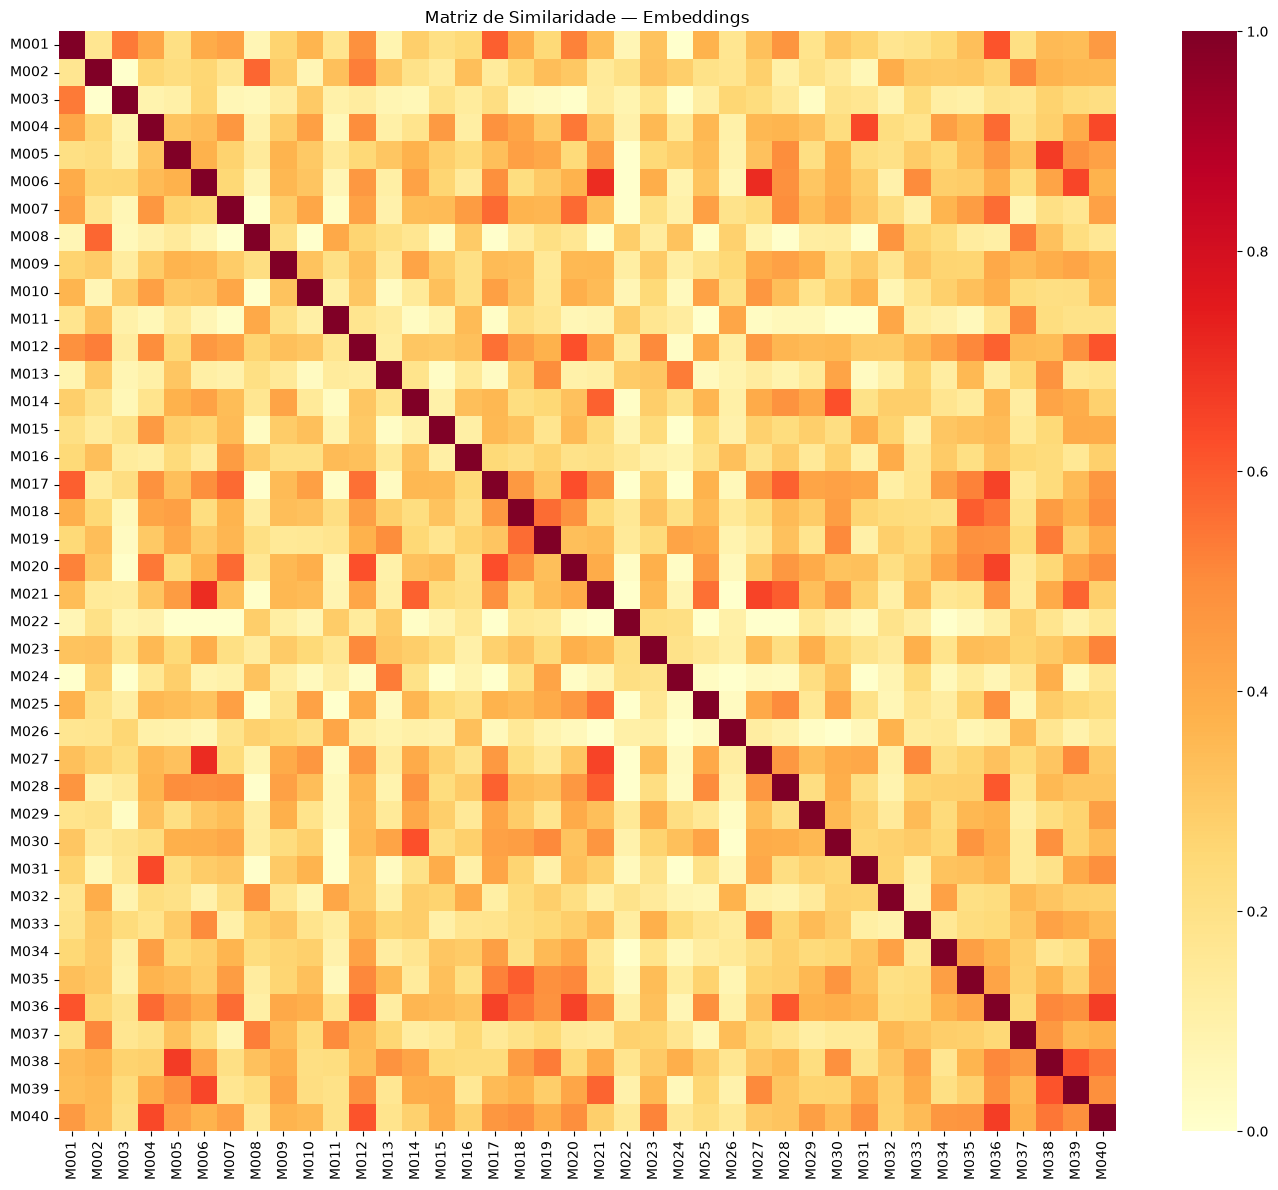

In [12]:
plt.figure(figsize=(14, 12))
sns.heatmap(matriz_sim, xticklabels=df['id'], yticklabels=df['id'],
            cmap='YlOrRd', vmin=0, vmax=1)
plt.title('Matriz de Similaridade — Embeddings')
plt.tight_layout()
plt.show()